In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("filer/eng.1.csv")

In [3]:
df

,Round,Date,Team 1,FT,Team 2
0,1,Sat Sep 12 2020,Fulham,0–3,Arsenal
1,1,Sat Sep 12 2020,Crystal Palace,1–0,Southampton
2,1,Sat Sep 12 2020,Liverpool,4–3,Leeds United
3,1,Sat Sep 12 2020,West Ham,0–2,Newcastle Utd
4,1,Sun Sep 13 2020,West Brom,0–3,Leicester City
...,...,...,...,...,...
375,38,Sun May 23 2021,West Ham,3–0,Southampton
376,38,Sun May 23 2021,Leeds United,3–1,West Brom
377,38,Sun May 23 2021,Arsenal,2–0,Brighton
378,38,Sun May 23 2021,Liverpool,2–0,Crystal Palace


In [6]:
df.loc[:, "HG"] = df.FT.str.split("–").apply(lambda x: x[0]).astype(int)
df.loc[:, "AG"] = df.FT.str.split("–").apply(lambda x: x[1]).astype(int)
df.loc[:, "Poäng"] = df.FT.str.split("–").apply(lambda x: x[0]).astype(int)
df

,Round,Date,Team 1,FT,Team 2,HG,AG,Poäng
0,1,Sat Sep 12 2020,Fulham,0–3,Arsenal,0,3,0
1,1,Sat Sep 12 2020,Crystal Palace,1–0,Southampton,1,0,1
2,1,Sat Sep 12 2020,Liverpool,4–3,Leeds United,4,3,4
3,1,Sat Sep 12 2020,West Ham,0–2,Newcastle Utd,0,2,0
4,1,Sun Sep 13 2020,West Brom,0–3,Leicester City,0,3,0
...,...,...,...,...,...,...,...,...
375,38,Sun May 23 2021,West Ham,3–0,Southampton,3,0,3
376,38,Sun May 23 2021,Leeds United,3–1,West Brom,3,1,3
377,38,Sun May 23 2021,Arsenal,2–0,Brighton,2,0,2
378,38,Sun May 23 2021,Liverpool,2–0,Crystal Palace,2,0,2


In [12]:
df.loc[:, "HG"] = df.FT.str.split("–").apply(lambda x: x[0]).astype(int)
df.loc[:, "AG"] = df.FT.str.split("–").apply(lambda x: x[1]).astype(int)

In [13]:
# Arsenal away wins
arsenal_hemma = df[(df["Team 2"] == "Arsenal") & (df["AG"] > df["HG"])]# hemma plan för Arsenal som vunnit 10
arsenal_hemma

,Round,Date,Team 1,FT,Team 2,HG,AG,Poäng
0,1,Sat Sep 12 2020,Fulham,0–3,Arsenal,0,3,0
66,7,Sun Nov 01 2020,Manchester Utd,0–1,Arsenal,0,1,0
155,16,Tue Dec 29 2020,Brighton,0–1,Arsenal,0,1,0
165,17,Sat Jan 02 2021,West Brom,0–4,Arsenal,0,4,0
193,20,Tue Jan 26 2021,Southampton,1–3,Arsenal,1,3,1
255,26,Sun Feb 28 2021,Leicester City,1–3,Arsenal,1,3,1
307,31,Sun Apr 11 2021,Sheffield Utd,0–3,Arsenal,0,3,0
335,34,Sun May 02 2021,Newcastle Utd,0–2,Arsenal,0,2,0
351,36,Wed May 12 2021,Chelsea,0–1,Arsenal,0,1,0
367,37,Wed May 19 2021,Crystal Palace,1–3,Arsenal,1,3,1


In [23]:
#  Skapa Winner-kolumn
df["Winner"] = df.apply(
    lambda row: row["Team 1"] if row["HG"] > row["AG"]
    else row["Team 2"] if row["AG"] > row["HG"]
    else "Draw",  # här sätter vi 'Draw' om oavgjort
    axis=1
)

# Separera vinster och oavgjorda
wins = df[df["Winner"] != "Draw"]
draws = df[df["Winner"] == "Draw"]

#  Räkna vinster per lag
wins_per_team = wins.groupby("Winner").size()
wins_per_team = wins_per_team.sort_values(ascending=False)
wins_per_team


Winner
Manchester City    27
Manchester Utd     21
Liverpool          20
Leicester City     20
West Ham           19
Chelsea            19
Leeds United       18
Tottenham          18
Arsenal            18
Everton            17
Aston Villa        16
Crystal Palace     12
Newcastle Utd      12
Southampton        12
Wolves             12
Burnley            10
Brighton            9
Sheffield Utd       7
Fulham              5
West Brom           5
dtype: int64

In [27]:
#vinster per lag med 3 poäng per vinst
wins_per_team1 = wins.groupby("Winner").size()*3
wins_per_team1 = wins_per_team1.sort_values(ascending=False)
wins_per_team1

Winner
Manchester City    81
Manchester Utd     63
Liverpool          60
Leicester City     60
West Ham           57
Chelsea            57
Leeds United       54
Tottenham          54
Arsenal            54
Everton            51
Aston Villa        48
Crystal Palace     36
Newcastle Utd      36
Southampton        36
Wolves             36
Burnley            30
Brighton           27
Sheffield Utd      21
Fulham             15
West Brom          15
dtype: int64

In [28]:
# Börja med 0 poäng, 0 vinster och 0 förluster
df["Poäng"] = 0
df["Vinster"] = 0
df["Förluster"] = 0

# Hemmalaget vinner → bortalaget förlorar
df.loc[df["HG"] > df["AG"], ["Poäng", "Vinster"]] = [3, 1]
df.loc[df["HG"] > df["AG"], "Förluster"] = 0  # hemmalaget förlorar inte
# bortalaget förlorar → markeras indirekt i nästa steg

# Bortalaget vinner → hemmalaget förlorar
df.loc[df["AG"] > df["HG"], ["Poäng", "Vinster"]] = [3, 1]
df.loc[df["AG"] > df["HG"], "Förluster"] = 0

# Oavgjort → 1 poäng, ingen vinst, ingen förlust
df.loc[df["HG"] == df["AG"], "Poäng"] = 1
df.loc[df["HG"] == df["AG"], "Förluster"] = 0


<Axes: xlabel='Winner'>

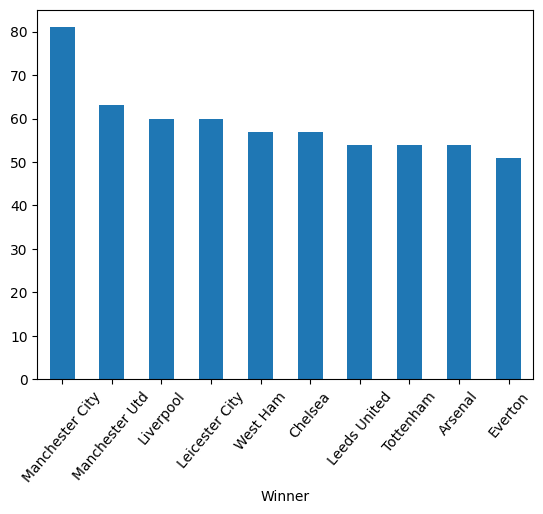

In [29]:
wins_per_team1.head(10).plot(kind='bar', rot = 50)

In [30]:
# Alla matcher som är oavgjorda
No_Winner = df[df["HG"] == df["AG"]]

# Räkna hur många oavgjorda varje lag har (både Team 1 och Team 2)
no_wins_per_team = pd.concat([No_Winner["Team 1"], No_Winner["Team 2"]]).value_counts()
no_wins_per_team

Brighton           14
Fulham             13
Manchester Utd     11
West Brom          11
Chelsea            10
Wolves              9
Burnley             9
Newcastle Utd       9
Liverpool           9
Crystal Palace      8
West Ham            8
Everton             8
Tottenham           8
Arsenal             7
Aston Villa         7
Southampton         7
Leicester City      6
Manchester City     5
Leeds United        5
Sheffield Utd       2
Name: count, dtype: int64

In [31]:
# Matcher där Team 1 förlorar
foluster_team1 = df[df["HG"] < df["AG"]]["Team 1"]

# Matcher där Team 2 förlorar
foluster_team2 = df[df["AG"] < df["HG"]]["Team 2"]

# Räkna förluster per lag
forlust_per_team = pd.concat([foluster_team1, foluster_team2]).value_counts()

forlust_per_team



Sheffield Utd      29
West Brom          22
Fulham             20
Burnley            19
Southampton        19
Crystal Palace     18
Newcastle Utd      17
Wolves             17
Aston Villa        15
Brighton           15
Leeds United       15
Everton            13
Arsenal            13
Tottenham          12
Leicester City     12
West Ham           11
Chelsea             9
Liverpool           9
Manchester City     6
Manchester Utd      6
Name: count, dtype: int64

<Axes: >

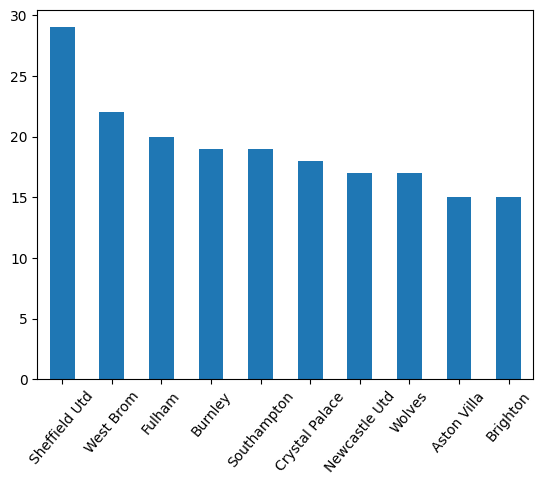

In [32]:
forlust_per_team.head(10).plot(kind='bar', rot = 50)

<Axes: >

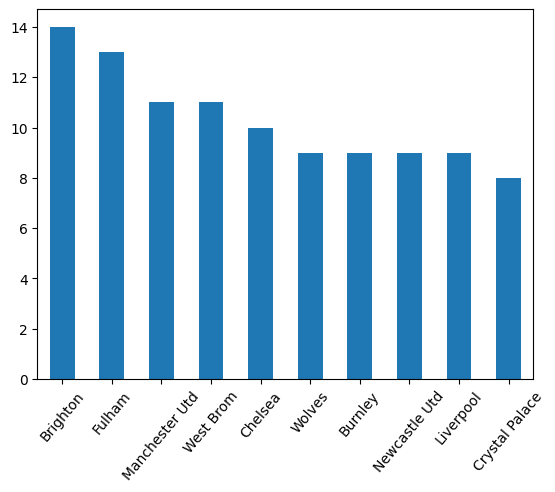

In [33]:
no_wins_per_team.head(10).plot(kind='bar', rot = 50)

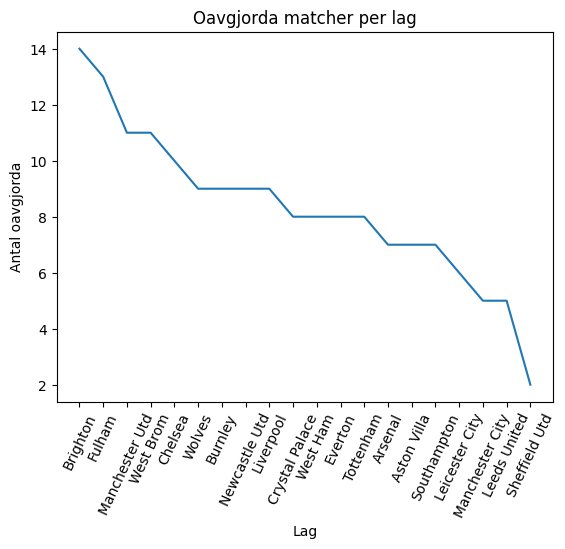

In [34]:
# mest oavgjorda matcher per lag
fig, ax = plt.subplots()

x = no_wins_per_team.index
y = no_wins_per_team.values

ax.plot(x, y)
ax.set_xlabel("Lag")
ax.set_ylabel("Antal oavgjorda")
ax.set_title("Oavgjorda matcher per lag")

plt.xticks(rotation=65)  
plt.show()


In [35]:
tabell = pd.DataFrame(df["Team 1"].unique(), columns=["Lag"])

In [36]:
df12 = pd.merge(tabell, wins_per_team.to_frame(name="Vinster"), left_on="Lag", right_on="Winner")# fyll på här sen
df12

,Lag,Vinster
0,Fulham,5
1,Crystal Palace,12
2,Liverpool,20
3,West Ham,19
4,West Brom,5
5,Tottenham,18
6,Sheffield Utd,7
7,Brighton,9
8,Burnley,10
9,Manchester City,27


In [37]:
df13 = pd.merge(df12, no_wins_per_team.to_frame(name="Oavgjorda"), left_on="Lag", right_index=True)
df13

,Lag,Vinster,Oavgjorda
0,Fulham,5,13
1,Crystal Palace,12,8
2,Liverpool,20,9
3,West Ham,19,8
4,West Brom,5,11
5,Tottenham,18,8
6,Sheffield Utd,7,2
7,Brighton,9,14
8,Burnley,10,9
9,Manchester City,27,5


In [38]:
df17 = pd.merge(wins_per_team.to_frame(),no_wins_per_team.to_frame(name="Oavgjorda") , left_on="Winner", right_index=True)
df17

,0,Oavgjorda
Winner,,
Manchester City,27,5
Manchester Utd,21,11
Liverpool,20,9
Leicester City,20,6
West Ham,19,8
Chelsea,19,10
Leeds United,18,5
Tottenham,18,8
Arsenal,18,7


<Axes: xlabel='Winner'>

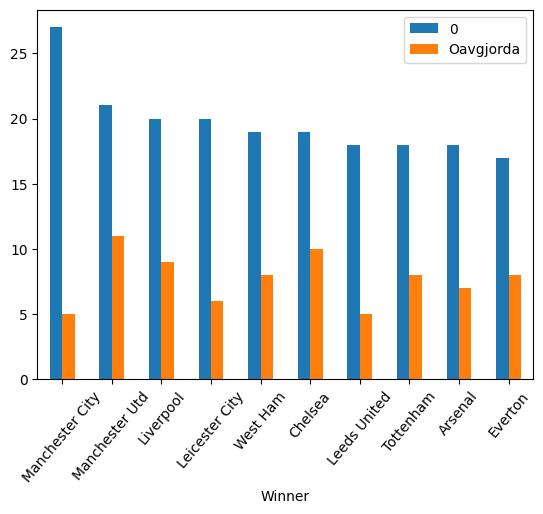

In [39]:
df17.head(10).plot(kind='bar', rot = 50)

In [40]:
df14 = wins_per_team1 + no_wins_per_team
df14

Arsenal            61
Aston Villa        55
Brighton           41
Burnley            39
Chelsea            67
Crystal Palace     44
Everton            59
Fulham             28
Leeds United       59
Leicester City     66
Liverpool          69
Manchester City    86
Manchester Utd     74
Newcastle Utd      45
Sheffield Utd      23
Southampton        43
Tottenham          62
West Brom          26
West Ham           65
Wolves             45
dtype: int64

In [41]:
df15 = pd.merge(df13, df14.to_frame(name="Poäng"), left_on="Lag", right_index=True)
df15_sorted = df15.sort_values(by="Poäng", ascending=False)
df15_sorted



,Lag,Vinster,Oavgjorda,Poäng
9,Manchester City,27,5,86
12,Manchester Utd,21,11,74
2,Liverpool,20,9,69
16,Chelsea,19,10,67
17,Leicester City,20,6,66
3,West Ham,19,8,65
5,Tottenham,18,8,62
13,Arsenal,18,7,61
10,Everton,17,8,59
11,Leeds United,18,5,59


In [43]:
df15_sorted["Rank"] = df15_sorted.sort_values("Poäng", ascending=False).reset_index(drop=True).index + 1
df15_sorted

,Lag,Vinster,Oavgjorda,Poäng,Rank
9,Manchester City,27,5,86,1
12,Manchester Utd,21,11,74,2
2,Liverpool,20,9,69,3
16,Chelsea,19,10,67,4
17,Leicester City,20,6,66,5
3,West Ham,19,8,65,6
5,Tottenham,18,8,62,7
13,Arsenal,18,7,61,8
10,Everton,17,8,59,9
11,Leeds United,18,5,59,10


,Lag,Vinster,Oavgjorda,Poäng,Rank
9,Manchester City,27,5,86,1
12,Manchester Utd,21,11,74,2
2,Liverpool,20,9,69,3
16,Chelsea,19,10,67,4
17,Leicester City,20,6,66,5
3,West Ham,19,8,65,6
5,Tottenham,18,8,62,7
13,Arsenal,18,7,61,8
10,Everton,17,8,59,9
11,Leeds United,18,5,59,10


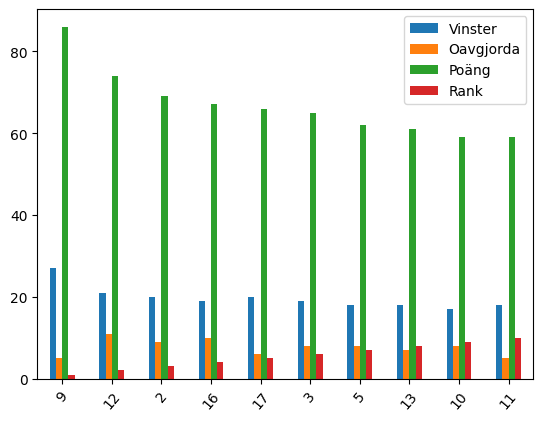

In [44]:
df15_sorted.head(10).plot(kind='bar', rot = 50) # fråga  Linus om detta
df15_sorted


In [45]:
#  Räkna vinster per lag och ge 3 poäng per vinst
points_per_team = wins.groupby("Winner").size() * 1
points_per_team = points_per_team.sort_values(ascending=False)

points_per_team


Winner
Manchester City    27
Manchester Utd     21
Liverpool          20
Leicester City     20
West Ham           19
Chelsea            19
Leeds United       18
Tottenham          18
Arsenal            18
Everton            17
Aston Villa        16
Crystal Palace     12
Newcastle Utd      12
Southampton        12
Wolves             12
Burnley            10
Brighton            9
Sheffield Utd       7
Fulham              5
West Brom           5
dtype: int64

In [46]:
# total vinster upp och ner, utan oavgjorda matcher
points_per_team = wins.groupby("Winner").size() * 3
points_per_team = points_per_team.sort_values(ascending=True)

points_per_team


Winner
West Brom          15
Fulham             15
Sheffield Utd      21
Brighton           27
Burnley            30
Wolves             36
Crystal Palace     36
Southampton        36
Newcastle Utd      36
Aston Villa        48
Everton            51
Tottenham          54
Arsenal            54
Leeds United       54
West Ham           57
Chelsea            57
Liverpool          60
Leicester City     60
Manchester Utd     63
Manchester City    81
dtype: int64

In [48]:
df = wins_per_team1 + no_wins_per_team
df

Arsenal            61
Aston Villa        55
Brighton           41
Burnley            39
Chelsea            67
Crystal Palace     44
Everton            59
Fulham             28
Leeds United       59
Leicester City     66
Liverpool          69
Manchester City    86
Manchester Utd     74
Newcastle Utd      45
Sheffield Utd      23
Southampton        43
Tottenham          62
West Brom          26
West Ham           65
Wolves             45
dtype: int64